Lab4 Exercise 

Registration Number: 23/EG/CO/027

In [1]:
# Import Project Dependencies
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from ydata_profiling import ProfileReport

C:\Users\Scientist\AppData\Local\Temp\ipykernel_8764\44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [3]:
# Create the results directory
results_dir = "../Output/results/lab4"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

In [4]:
# Configure the plotting theme for image consistency
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 14, "axes.labelsize": 12, "axes.titlesize": 14})

In [5]:
# Load dataset
file_path = "../Datasets/ai4i2020.csv"
data = pd.read_csv(file_path)

In [6]:
# Inpect Data
print("\nFirst 5 Records")
data.head()


First 5 Records


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
# Display Data Features
print("\nFeatures Names and Data Types")
data.info()


Features Names and Data Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64

In [8]:
# Rename the data headers into clean operational variable names
data.columns = [
'UDI', 'Product_ID', 'Type', 'Air_Temperature', 'Process_Temperature',
'Rotational_Speed', 'Torque', 'Tool_Wear', 'Machine_Failure',
'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
]


In [9]:
# Examine the dataset dimensions
print(f"\nDataset Dimensions: {data.shape[0]} rows, {data.shape[1]} columns")


Dataset Dimensions: 10000 rows, 14 columns


In [10]:
# Generate the descriptive statistics for the numerical and categorical operating parameters
print("\nDescriptive Statistics")
data.describe().T



Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air_Temperature,10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process_Temperature,10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational_Speed,10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque,10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool_Wear,10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine_Failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [11]:
# Generate descriptive statistics for the categorical operating parameters
print("\nDescriptive Statistics")
data.describe(include=["object"]).T


Descriptive Statistics


,count,unique,top,freq
Product_ID,10000,10000,M14860,1
Type,10000,3,L,6000


In [12]:
# Examine target variable, its class and frequencies
print("\nTarget Class Counts (Machine_Failure)")
print(data['Machine_Failure'].value_counts())


Target Class Counts (Machine_Failure)
Machine_Failure
0    9661
1     339
Name: count, dtype: int64


In [13]:
# Examine the target class proportions/Percentage
print("\nTarget Class Proportions")
data['Machine_Failure'].value_counts(normalize=True).round(4)*100



Target Class Proportions


Machine_Failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [14]:
# Check for missing values across all columns
print("\nMissing Values per Column")
data.isnull().sum()



Missing Values per Column


UDI                    0
Product_ID             0
Type                   0
Air_Temperature        0
Process_Temperature    0
Rotational_Speed       0
Torque                 0
Tool_Wear              0
Machine_Failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

In [15]:
# Remove duplicates detected
print(f"\nDuplicate rows found: {data.duplicated().sum()}")
if data.duplicated().sum() > 0:
    data.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {data.shape}")




Duplicate rows found: 0


In [16]:
# Convert the categorical Machine Type into ordinal Integer
type_mapping = {'L': 0, 'M': 1, 'H': 2}
data['Type_Ordinal'] = data['Type'].map(type_mapping)

print("\nMachine Type Encoding (L=0, M=1, H=2)")
print(data[['Type', 'Type_Ordinal']].drop_duplicates().to_string(index=False))



Machine Type Encoding (L=0, M=1, H=2)
Type  Type_Ordinal
   M             1
   L             0
   H             2


In [17]:
# Generate full automated EDA report
profile = ProfileReport(data, title='AI4I 2020 Predictive MaintenanceProfiling Report')
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 25.65it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
# Define sensor features
sensor_cols = ['Air_Temperature', 'Process_Temperature',
'Rotational_Speed', 'Torque', 'Tool_Wear']


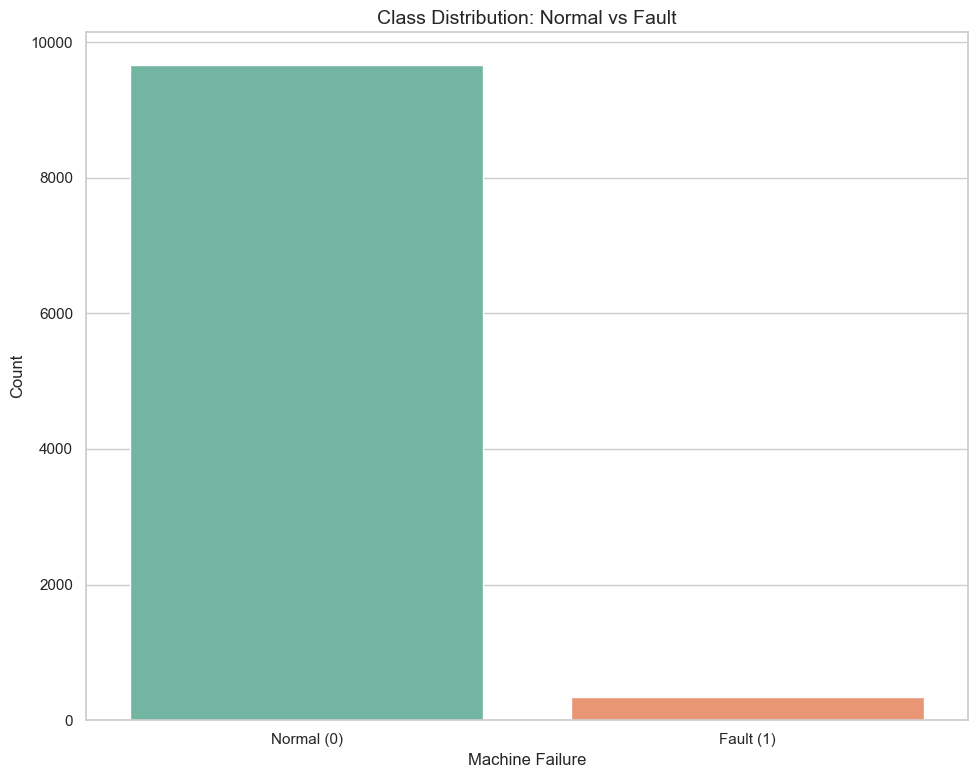

In [19]:
# Plot class distribution showing how balanced the fault classes are.
plt.figure(figsize=(10, 8))
sns.countplot(data=data, x='Machine_Failure', hue='Machine_Failure', palette='Set2', legend=False)
plt.xticks([0, 1], ['Normal (0)', 'Fault (1)'])
plt.title("Class Distribution: Normal vs Fault")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(results_dir + "class_distribution.png", dpi=300)
plt.show()


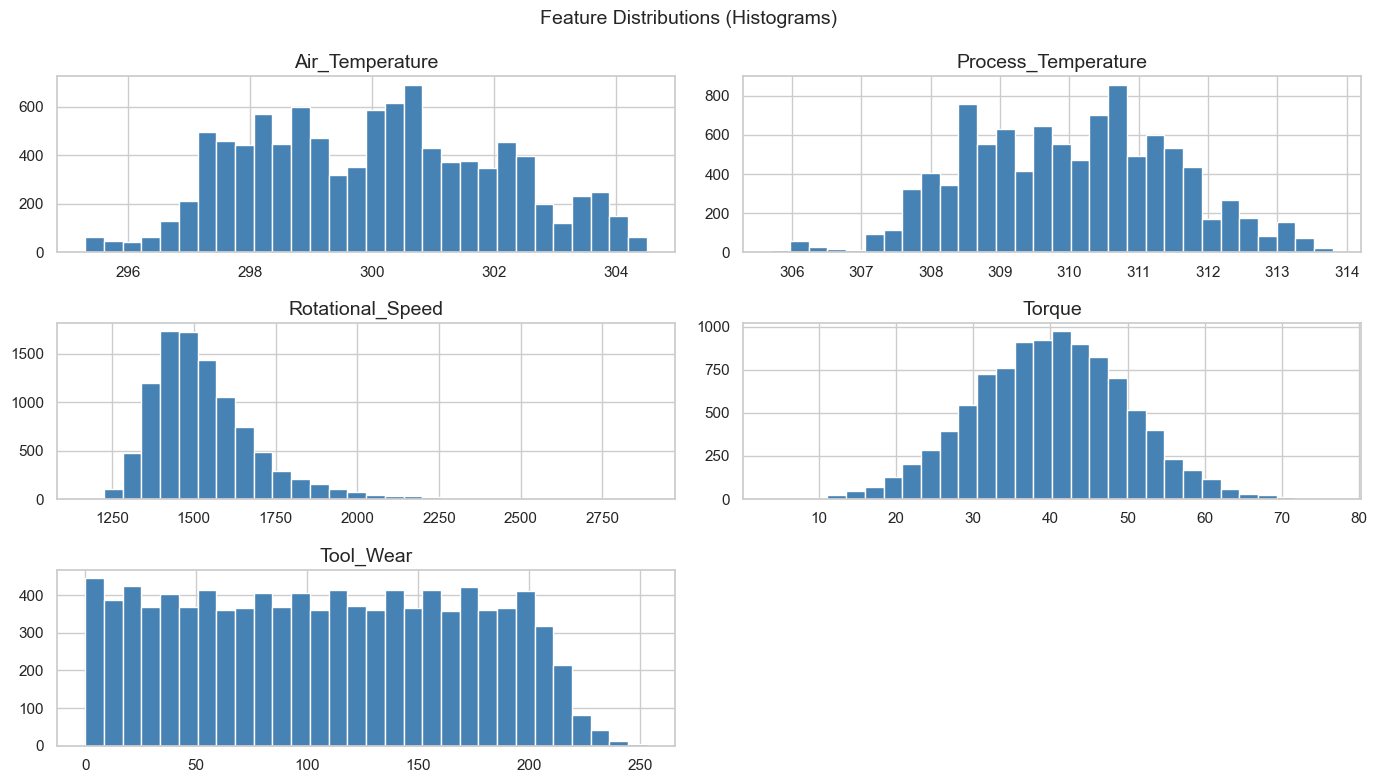

In [20]:
# Histogram to show the distribution/speed of every sensor feature
data[sensor_cols].hist(figsize=(14, 8), bins=30, color='steelblue',
edgecolor='white')
plt.suptitle("Feature Distributions (Histograms)", fontsize=14)
plt.tight_layout()
plt.show()


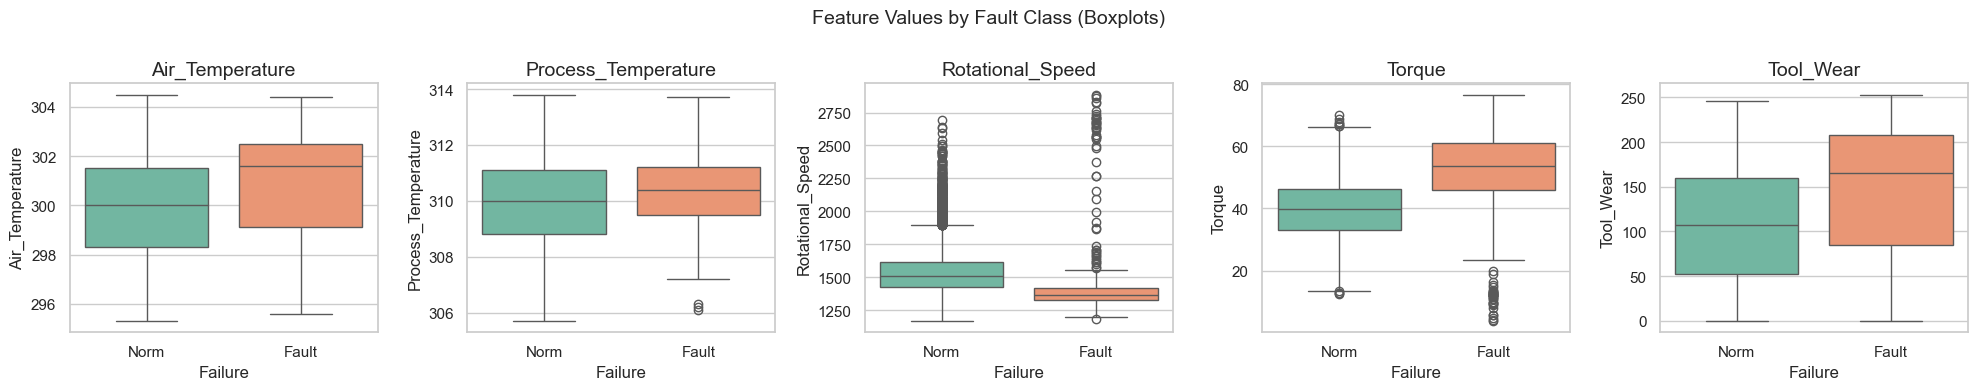

In [21]:
# Box plot to show which features differ between Normal and Fault.
fig, axes = plt.subplots(1, len(sensor_cols), figsize=(20, 4))
for ax, col in zip(axes, sensor_cols):
    sns.boxplot(data=data, x='Machine_Failure', y=col, hue='Machine_Failure',
    palette='Set2', ax=ax, legend=False)
    ax.set_title(col)
    ax.set_xlabel("Failure")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Norm', 'Fault'])
plt.suptitle("Feature Values by Fault Class (Boxplots)", fontsize=14)
plt.tight_layout()
plt.show()


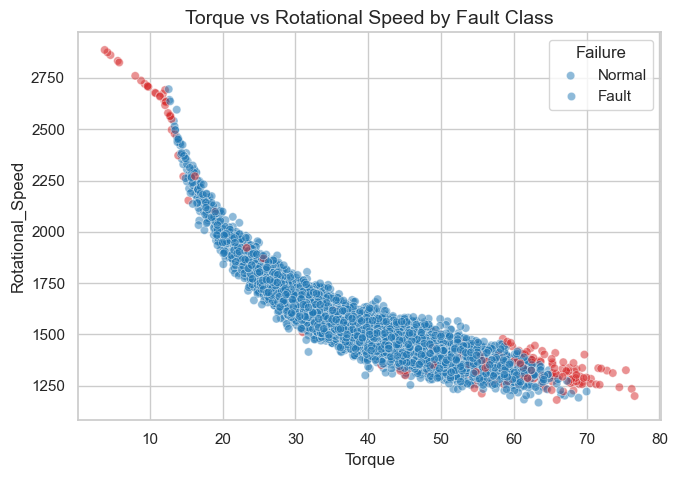

In [22]:
# Scatterplot of Torque vs. Rotational speed
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='Torque', y='Rotational_Speed', hue='Machine_Failure', palette={0: 'tab:blue', 1: 'tab:red'}, alpha=0.5)
plt.title("Torque vs Rotational Speed by Fault Class")
plt.legend(title="Failure", labels=['Normal', 'Fault'])
plt.tight_layout()
plt.show()


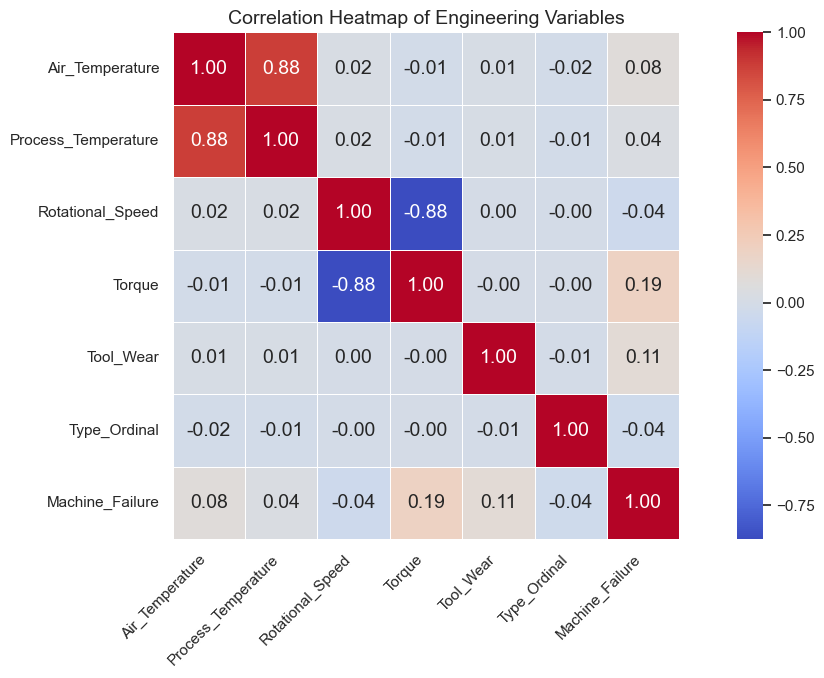

In [23]:
# Build correlation matrix and visualize its heatmap
corr_cols = sensor_cols + ['Type_Ordinal', 'Machine_Failure']
corr_matrix = data[corr_cols].corr()
plt.figure(figsize=(12, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Engineering Variables")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [24]:
# Seperate the predictor variable(X) from the target (y).
X_raw = data.drop(columns=['UDI', 'Product_ID', 'Type', 'Machine_Failure',
'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = data['Machine_Failure']
print("Predictor features used:", list(X_raw.columns))

Predictor features used: ['Air_Temperature', 'Process_Temperature', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Type_Ordinal']


In [25]:
# Split into stratified 80% training and 20% test set.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X_raw, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set: {X_train.shape[0]} rows ")
print(f"Test set: {X_test.shape[0]} rows")
print(f"\nTrain fault ratio: {y_train.mean():.4f}")
print(f"Test fault ratio: {y_test.mean():.4f}")


Training set: 8000 rows 
Test set: 2000 rows

Train fault ratio: 0.0339
Test fault ratio: 0.0340


In [26]:
# Standardize the features for the distance/margin-based models
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
# Convert the scaled training data to DataFrame with the same column
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

In [28]:
# Convert the scaled testing DataFrame with the same column
X_test_scaled_df = pd.DataFrame(X_test_scaled,columns=X_test.columns, index=X_test.index)

In [29]:
# Get the descsriptive statistics of the scaled X trained.
print("\Descriptive statistis of the scaled training rows (as DataFrame):")
X_train_scaled_df.describe().T.round(4)

\Descriptive statistis of the scaled training rows (as DataFrame):


<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Scientist\AppData\Local\Temp\ipykernel_8764\3949690402.py:2: SyntaxWarning: invalid escape sequence '\D'
  print("\Descriptive statistis of the scaled training rows (as DataFrame):")


,count,mean,std,min,25%,50%,75%,max
Air_Temperature,8000.0,0.0,1.0001,-2.3566,-0.8541,0.0474,0.7485,2.2510
Process_Temperature,8000.0,0.0,1.0001,-2.9108,-0.8153,0.0635,0.7395,2.5646
Rotational_Speed,8000.0,0.0,1.0001,-2.0520,-0.6485,-0.2009,0.4069,7.4412
Torque,8000.0,-0.0,1.0001,-3.6135,-0.6791,0.0096,0.6784,3.6528
Tool_Wear,8000.0,-0.0,1.0001,-1.6929,-0.8597,-0.0108,0.8696,2.2845
Type_Ordinal,8000.0,0.0,1.0001,-0.7400,-0.7400,-0.7400,0.7553,2.2507


In [30]:
# Get the descsriptive statistics for the Scaled X test
print("\Descriptive statistis of the scaled training rows (as DataFrame):")
X_test_scaled_df.describe().T.round(4)


<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Scientist\AppData\Local\Temp\ipykernel_8764\3555655388.py:2: SyntaxWarning: invalid escape sequence '\D'
  print("\Descriptive statistis of the scaled training rows (as DataFrame):")


\Descriptive statistis of the scaled training rows (as DataFrame):


,count,mean,std,min,25%,50%,75%,max
Air_Temperature,2000.0,-0.0013,1.0088,-2.3566,-0.8040,0.0474,0.7485,2.2009
Process_Temperature,2000.0,-0.0017,1.0148,-2.8432,-0.7477,0.0635,0.7395,2.4294
Rotational_Speed,2000.0,-0.0160,0.9523,-1.8641,-0.6319,-0.2009,0.3848,7.1041
Torque,2000.0,-0.0082,0.9748,-3.4139,-0.6791,-0.0003,0.6484,3.1936
Tool_Wear,2000.0,0.0209,1.0034,-1.6929,-0.8440,0.0678,0.8382,2.1745
Type_Ordinal,2000.0,0.0406,1.0183,-0.7400,-0.7400,-0.7400,0.7553,2.2507


In [31]:
# Train the logistic Regression Classifier on the scaled features
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced',
random_state=42)
lr_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [32]:
# Inspect the learned coefficients
print("\n[INSPECTION] Logistic Regression Coefficients (decision boundary weights):\n")
for feat, coef in zip(X_raw.columns, lr_model.coef_[0]):
    print(f" Feature '{feat}': Weight = {coef:.4f}")
print(f" Intercept (bias) = {lr_model.intercept_[0]:.4f}")



[INSPECTION] Logistic Regression Coefficients (decision boundary weights):

 Feature 'Air_Temperature': Weight = 1.7771
 Feature 'Process_Temperature': Weight = -1.2304
 Feature 'Rotational_Speed': Weight = 1.7279
 Feature 'Torque': Weight = 2.4040
 Feature 'Tool_Wear': Weight = 0.8657
 Feature 'Type_Ordinal': Weight = -0.2135
 Intercept (bias) = -1.4741


In [33]:
# Make a single prediction on one example machine reading
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)
print("\nSingle-sample prediction (1=Fault, 0=Normal):\n")
print("Actual:", y_test.iloc[0])
print("Predicted: ", lr_model.predict(sample_scaled)[0])


Single-sample prediction (1=Fault, 0=Normal):

Actual: 0
Predicted:  1


In [34]:
# Predict on the full set and build an actual vs predicted table
y_pred_lr = lr_model.predict(X_test_scaled)
print("\nActual vs Predicted (first 20 test rows):")
lr_compare_df = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred_lr})
print(lr_compare_df.head(20).to_string(index=False))



Actual vs Predicted (first 20 test rows):
 Actual  Predicted
      0          1
      0          1
      0          1
      0          0
      0          1
      0          1
      0          1
      0          0
      0          0
      0          1
      0          0
      0          0
      0          0
      0          0
      0          0
      0          1
      0          0
      1          1
      0          0
      0          0


In [35]:
# Evaluate Logistic Regression Performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("\nLogistic Regression Classification Report")
print(classification_report(
y_test, y_pred_lr, target_names=['Normal', 'Fault'],
digits=4, zero_division=0))

print(f"Accuracy: {acc_lr:.2%}")
print(f"Precision: {prec_lr:.2%}")
print(f"Recall: {rec_lr:.2%}")
print(f"F1: {f1_lr:.2%}")



Logistic Regression Classification Report
              precision    recall  f1-score   support

      Normal     0.9925    0.8204    0.8983      1932
       Fault     0.1390    0.8235    0.2378        68

    accuracy                         0.8205      2000
   macro avg     0.5657    0.8220    0.5680      2000
weighted avg     0.9635    0.8205    0.8758      2000

Accuracy: 82.05%
Precision: 13.90%
Recall: 82.35%
F1: 23.78%


In [36]:
# Experiment with different values of K to see the effect on the F1-Score
from sklearn.neighbors import KNeighborsClassifier
print("\nKNN: Effect of K on F1-Score")
for k in [3, 5, 7, 9, 11, 15]:
    tmp = KNeighborsClassifier(n_neighbors=k, weights='distance')
    tmp.fit(X_train_scaled, y_train)
    tmp_f1 = f1_score(y_test, tmp.predict(X_test_scaled), zero_division=0)

print(f" K = {k:>2} -> F1 = {tmp_f1:.4f}")


KNN: Effect of K on F1-Score
 K = 15 -> F1 = 0.2532


In [37]:
# Train the Remaining kNN classifier (K=5, distance weighted) and evaluate 
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, zero_division=0)
rec_knn = recall_score(y_test, y_pred_knn, zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, zero_division=0)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("\nLogistic Regression Classification Report")
print(classification_report(y_test, y_pred_knn, target_names=['Normal', 'Fault'], digits=4, zero_division=0))
print(f"Accuracy: {acc_knn:.2%}")
print(f"Precision: {prec_knn:.2%}")
print(f"Recall: {rec_knn:.2%}")
print(f"F1: {f1_knn:.2%}")


Logistic Regression Classification Report
              precision    recall  f1-score   support

      Normal     0.9772    0.9979    0.9875      1932
       Fault     0.8519    0.3382    0.4842        68

    accuracy                         0.9755      2000
   macro avg     0.9145    0.6681    0.7358      2000
weighted avg     0.9729    0.9755    0.9703      2000

Accuracy: 97.55%
Precision: 85.19%
Recall: 33.82%
F1: 48.42%


In [38]:
# Experiment wit linear RBF kernels to fins the best boundary
from sklearn.svm import SVC
print("\nSVM: Linear vs RBF Kernel (F1-Score)")
for kern in ['linear', 'rbf']:
    tmp = SVC(kernel=kern, C=5.0,
    class_weight='balanced', random_state=42)
    
tmp.fit(X_train_scaled, y_train)
tmp_f1 = f1_score(y_test, tmp.predict(X_test_scaled), zero_division=0)
print(f" Kernel = {kern:>6} -> F1 = {tmp_f1:.4f}")



SVM: Linear vs RBF Kernel (F1-Score)
 Kernel =    rbf -> F1 = 0.4683


In [39]:
# Train the final SVM and inspect its support vectors
svm_model = SVC(kernel='rbf', C=5.0, class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)
print("\nNumber of support vectors per class [Normal, Fault]:")
print(svm_model.n_support_)



Number of support vectors per class [Normal, Fault]:
[1249   98]


In [40]:
# Predict on the Test set and evaluate the SVM
y_pred_svm = svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("\nLogistic Regression Classification Report")
print(classification_report(
        y_test, y_pred_svm, target_names=['Normal', 'Fault'],
        digits=4, zero_division=0))
print(f"Accuracy: {acc_svm:.2%}")
print(f"Precision: {prec_svm:.2%}")
print(f"Recall: {rec_svm:.2%}")
print(f"F1: {f1_svm:.2%}")



Logistic Regression Classification Report
              precision    recall  f1-score   support

      Normal     0.9950    0.9353    0.9642      1932
       Fault     0.3207    0.8676    0.4683        68

    accuracy                         0.9330      2000
   macro avg     0.6578    0.9015    0.7163      2000
weighted avg     0.9721    0.9330    0.9474      2000

Accuracy: 93.30%
Precision: 32.07%
Recall: 86.76%
F1: 46.83%


In [41]:
# Experiment with differenet tree depths (watch for overfiting)
from sklearn.tree import DecisionTreeClassifier
print("\nDecision Tree: Effect of max_depth (Test F1)")
for d in [3, 5, 8, 12, None]:
    tmp = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
    random_state=42)

# trees do NOT need scaling -> use raw features
tmp.fit(X_train, y_train)
tmp_f1 = f1_score(y_test, tmp.predict(X_test), zero_division=0)
print(f" max_depth = {str(d):>4} -> F1 = {tmp_f1:.4f}")


Decision Tree: Effect of max_depth (Test F1)
 max_depth = None -> F1 = 0.6667


In [42]:
# Train the final decision tree on the unscaled features and predict
dt_model = DecisionTreeClassifier(max_depth=None, class_weight='balanced',
random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

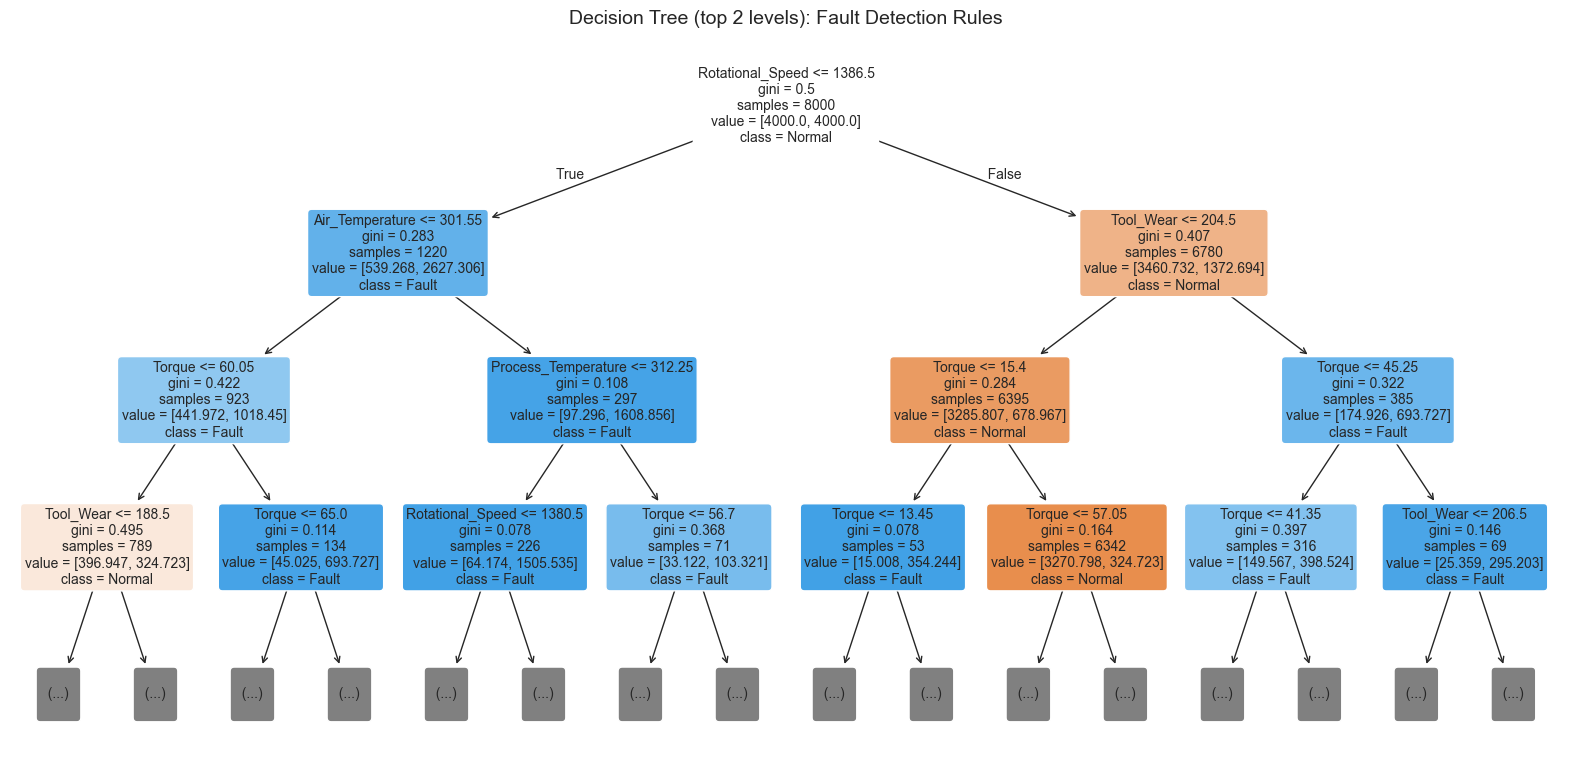

In [43]:
# Visualize the top of the tree to interpret the decision rules
from sklearn.tree import plot_tree
plt.figure(figsize=(16, 8))
plot_tree(dt_model, feature_names=list(X_raw.columns),
class_names=['Normal', 'Fault'], max_depth=3, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree (top 2 levels): Fault Detection Rules")
plt.tight_layout()
plt.show()

In [44]:
# Evaluate the decision Tree
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("\nLogistic Regression Classification Report")
print(classification_report(
    y_test, y_pred_dt, target_names=['Normal', 'Fault'],
    digits=4, zero_division=0))
print(f"Accuracy: {acc_dt:.2%}")
print(f"Precision: {prec_dt:.2%}")
print(f"Recall: {rec_dt:.2%}")
print(f"F1: {f1_dt:.2%}")



Logistic Regression Classification Report
              precision    recall  f1-score   support

      Normal     0.9871    0.9907    0.9889      1932
       Fault     0.7049    0.6324    0.6667        68

    accuracy                         0.9785      2000
   macro avg     0.8460    0.8115    0.8278      2000
weighted avg     0.9775    0.9785    0.9779      2000

Accuracy: 97.85%
Precision: 70.49%
Recall: 63.24%
F1: 66.67%


In [45]:
# Experiment with the number of trees in the ensemble
from sklearn.ensemble import RandomForestClassifier
print("\nRandom Forest: Effect of n_estimators (Test F1)")
for n in [50, 100, 150, 300]:
    tmp = RandomForestClassifier(n_estimators=n,
    class_weight='balanced',
    random_state=42)
tmp.fit(X_train, y_train)
tmp_f1 = f1_score(y_test, tmp.predict(X_test), zero_division=0)
print(f" n_estimators = {n:>3} -> F1 = {tmp_f1:.4f}")


Random Forest: Effect of n_estimators (Test F1)
 n_estimators = 300 -> F1 = 0.7669


In [46]:
# Train the final Random Forest on the 150 Trees
rf_model = RandomForestClassifier(n_estimators=150, class_weight='balanced',
random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [47]:
# Evaluate the Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nLogistic Regression Classification Report")
print(classification_report(y_test, y_pred_rf, target_names=['Normal',
 'Fault'],
 digits=4, zero_division=0))
print(f"Accuracy: {acc_rf:.2%}")
print(f"Precision: {prec_rf:.2%}")
print(f"Recall: {rec_rf:.2%}")
print(f"F1: {f1_rf:.2%}")


Logistic Regression Classification Report
              precision    recall  f1-score   support

      Normal     0.9907    0.9933    0.9920      1932
       Fault     0.7937    0.7353    0.7634        68

    accuracy                         0.9845      2000
   macro avg     0.8922    0.8643    0.8777      2000
weighted avg     0.9840    0.9845    0.9842      2000

Accuracy: 98.45%
Precision: 79.37%
Recall: 73.53%
F1: 76.34%


In [50]:
# Derive TN, FP, FN, and TP for every model
saved_matrices = {
"Logistic Regression": cm_lr, "K-Nearest Neighbors": cm_knn,
"Support Vector Machine": cm_svm, "Decision Tree": cm_dt, "RandomForest": cm_rf}
print("\nTrue/False Positives & Negatives per Model")
for name, cm in saved_matrices.items():
    tn, fp, fn, tp = cm.ravel()
    print(f" {name:<24} TN={tn:<5} FP={fp:<4} FN={fn:<4} TP={tp}")


True/False Positives & Negatives per Model
 Logistic Regression      TN=1585  FP=347  FN=12   TP=56
 K-Nearest Neighbors      TN=1928  FP=4    FN=45   TP=23
 Support Vector Machine   TN=1807  FP=125  FN=9    TP=59
 Decision Tree            TN=1914  FP=18   FN=25   TP=43
 RandomForest             TN=1919  FP=13   FN=18   TP=50


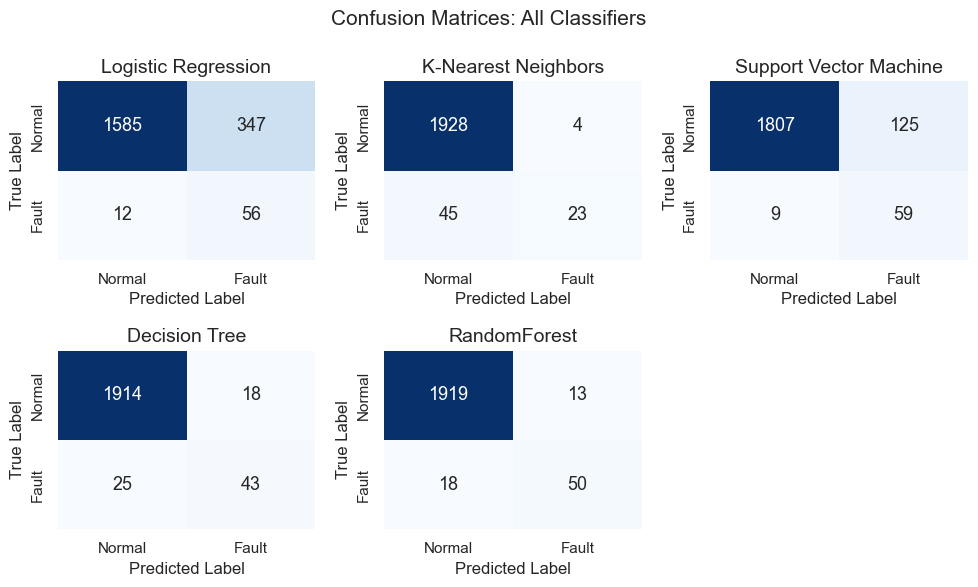

In [52]:
# Plot all confusion matrix side by side for comparison
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes_flat = axes.flatten()
for idx, (name, cm) in enumerate(saved_matrices.items()):
        sns.heatmap(cm, annot=True, fmt="d",
        cmap="Blues", cbar=False, ax=axes_flat[idx],
        xticklabels=['Normal', 'Fault'],
        yticklabels=['Normal', 'Fault'],
        annot_kws={"size": 13})
        axes_flat[idx].set_title(f"{name}")
        axes_flat[idx].set_xlabel("Predicted Label")
        axes_flat[idx].set_ylabel("True Label")
fig.delaxes(axes_flat[-1]) # remove the empty 6th panel
plt.suptitle("Confusion Matrices: All Classifiers", fontsize=15)
plt.tight_layout()
plt.show()


In [53]:
#   Compile every model's metrics into one comparison table
comparison_df = pd.DataFrame({"Model": ["Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine", "Decision Tree", "Random Forest"],
"Accuracy": [acc_lr, acc_knn, acc_svm, acc_dt, acc_rf],
"Precision": [prec_lr, prec_knn, prec_svm, prec_dt, prec_rf],
"Recall (Fault)": [rec_lr, rec_knn, rec_svm, rec_dt, rec_rf],
"F1-Score": [f1_lr, f1_knn, f1_svm, f1_dt, f1_rf]
})

# Sorted explicitly in ascending order by Recall (Fault)
print(" CONSOLIDATED FAULT CLASSIFICATION PERFORMANCE COMPARISON\n")
print(comparison_df.sort_values(by="Recall (Fault)", ascending=False))


 CONSOLIDATED FAULT CLASSIFICATION PERFORMANCE COMPARISON

                    Model  Accuracy  Precision  Recall (Fault)  F1-Score
2  Support Vector Machine    0.9330   0.320652        0.867647  0.468254
0     Logistic Regression    0.8205   0.138958        0.823529  0.237792
4           Random Forest    0.9845   0.793651        0.735294  0.763359
3           Decision Tree    0.9785   0.704918        0.632353  0.666667
1     K-Nearest Neighbors    0.9755   0.851852        0.338235  0.484211


In [54]:
# Extract the rank feature importances from the tree-based models
importance_df = pd.DataFrame({
    'Engineering Variable': X_raw.columns,
    'Decision Tree Importance': dt_model.feature_importances_,
    'Random Forest Importance': rf_model.feature_importances_
    }).sort_values(by="Random Forest Importance", ascending=False)

print(" ENGINEERING VARIABLE IMPORTANCE RANKING (TREE MODELS)\n")
print(importance_df.to_string(index=False))


 ENGINEERING VARIABLE IMPORTANCE RANKING (TREE MODELS)

Engineering Variable  Decision Tree Importance  Random Forest Importance
              Torque                  0.314328                  0.361504
    Rotational_Speed                  0.333022                  0.262384
           Tool_Wear                  0.258067                  0.211493
     Air_Temperature                  0.051100                  0.095527
 Process_Temperature                  0.033002                  0.056029
        Type_Ordinal                  0.010481                  0.013063


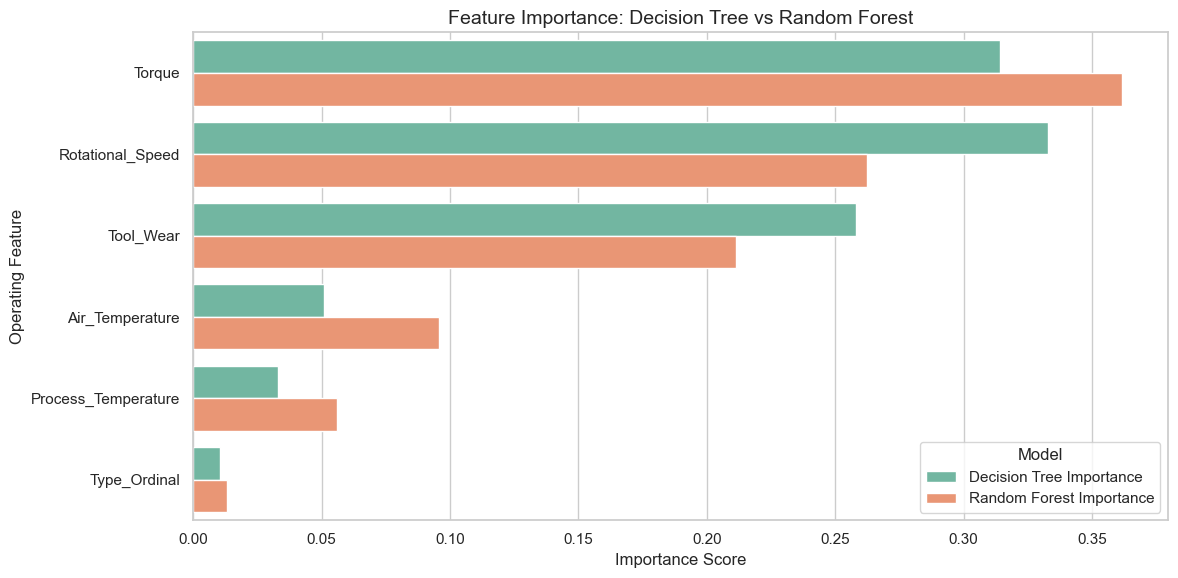

In [55]:
# plot the feature importances side-by-side
plt.figure(figsize=(12, 6))
importance_melted = pd.melt(importance_df, id_vars=['Engineering Variable'], value_vars=['Decision Tree Importance', 'Random Forest Importance'], var_name='Model', value_name='Importance')
sns.barplot(data=importance_melted, x='Importance', y='Engineering Variable', hue='Model', palette='Set2')
plt.title("Feature Importance: Decision Tree vs Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Operating Feature")
plt.tight_layout()
plt.show()

